In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

# Nếu notebook đang chạy trong thư mục notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

# Tạo thư mục outputs nếu chưa tồn tại
output_directory = PROJECT_ROOT / "outputs"
output_directory.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_directory)

Project root: d:\Project_Intern\us-real-interest-rate-analysis
Output directory: d:\Project_Intern\us-real-interest-rate-analysis\outputs


In [5]:
import os
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")
fred_api_key = os.getenv("FRED_API_KEY")

from matplotlib import dates as mdates
from matplotlib import pyplot as plt

from src.data_loader import load_interest_rate_data

from src.calculations import (
    build_analysis_dataset,
    get_data_status,
    get_latest_metrics,
)

In [6]:
# Lấy dữ liệu
raw_data = load_interest_rate_data(
    api_key=fred_api_key,
    start_date="2000-01-01",
)

nominal_df = raw_data["nominal_rate"]
expected_df = raw_data["expected_inflation"]

In [7]:
# Tìm lãi suất thực
analysis_df = build_analysis_dataset(
    nominal_df=nominal_df,
    expected_df=expected_df,
)

analysis_df.tail()

,nominal_rate,expected_inflation,real_rate_approx,real_rate_exact,formula_difference,negative_real_rate
date,,,,,,
2026-03-01,3.61,2.295295,1.314705,1.285206,0.029499,False
2026-04-01,3.61,3.276398,0.333602,0.323019,0.010583,False
2026-05-01,3.60,3.535256,0.064744,0.062534,0.002211,False
2026-06-01,3.66,3.038866,0.621134,0.602815,0.018319,False
2026-07-01,3.73,2.386001,1.343999,1.312678,0.031321,False


In [9]:
# Xác định khoảng thời gian của biểu đồ
chart_start_date = analysis_df.index.min()
chart_end_date = analysis_df.index.max()

chart_start_year = chart_start_date.year
chart_end_year = chart_end_date.year

print(
    f"Chart period: "
    f"{chart_start_date.strftime('%Y-%m')} "
    f"to {chart_end_date.strftime('%Y-%m')}"
)

Chart period: 2000-01 to 2026-07


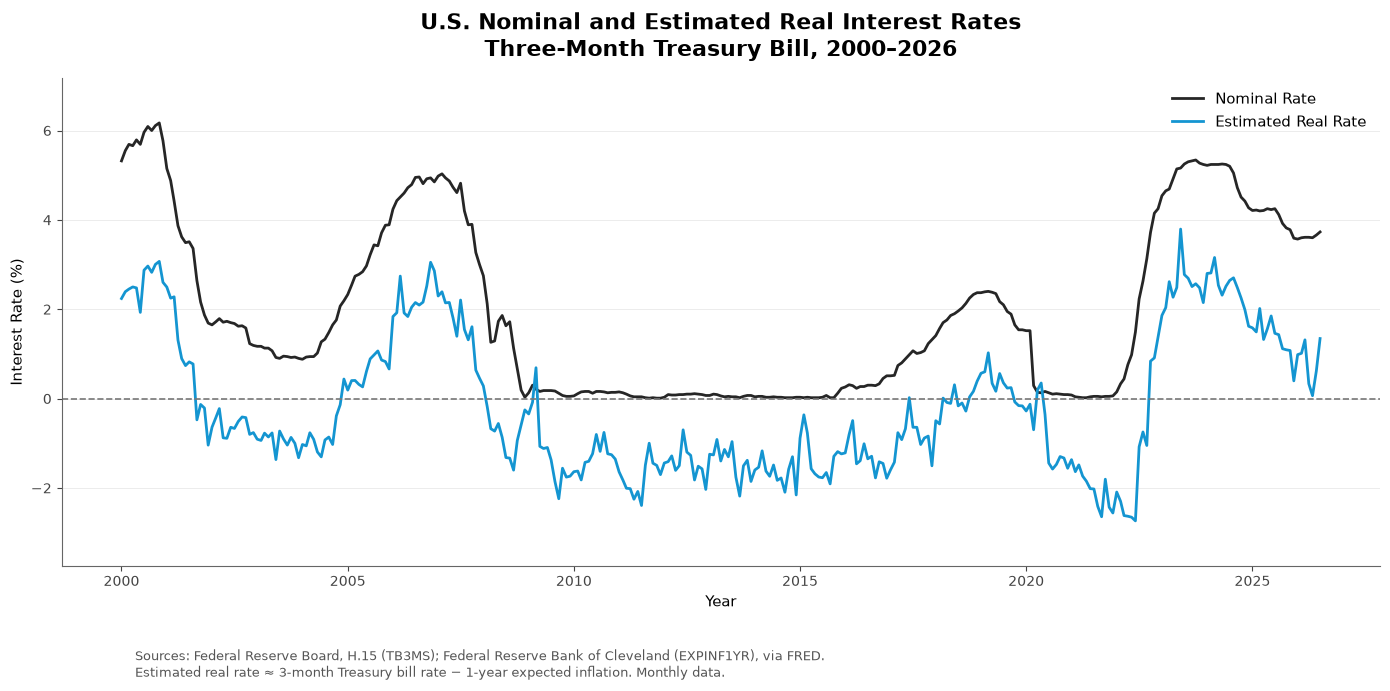

Figure saved to: d:\Project_Intern\us-real-interest-rate-analysis\outputs\nominal_and_real_interest_rates.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Nominal interest rate
ax.plot(
    analysis_df.index,
    analysis_df["nominal_rate"],
    color="#262626",
    linewidth=2,
    label="Nominal Rate"
)

# Estimated real interest rate
ax.plot(
    analysis_df.index,
    analysis_df["real_rate_approx"],
    color="#1495D1",
    linewidth=2,
    label="Estimated Real Rate"
)

# Zero-percent reference line
ax.axhline(
    y=0,
    color="#777777",
    linewidth=1.2,
    linestyle="--"
)

ax.set_title(
    "U.S. Nominal and Estimated Real Interest Rates\n"
    f"Three-Month Treasury Bill, "
    f"{chart_start_year}–{chart_end_year}",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Interest Rate (%)", fontsize=11)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

minimum_rate = min(
    analysis_df["nominal_rate"].min(),
    analysis_df["real_rate_approx"].min()
)

maximum_rate = max(
    analysis_df["nominal_rate"].max(),
    analysis_df["real_rate_approx"].max()
)

ax.set_ylim(minimum_rate - 1, maximum_rate + 1)

ax.grid(
    axis="y",
    color="#D9D9D9",
    linestyle="-",
    linewidth=0.7,
    alpha=0.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")

ax.tick_params(axis="both", colors="#444444")
ax.legend(loc="upper right", frameon=False, fontsize=11)

source_note = (
    "Sources: Federal Reserve Board, H.15 (TB3MS); "
    "Federal Reserve Bank of Cleveland (EXPINF1YR), via FRED.\n"
    "Estimated real rate ≈ 3-month Treasury bill rate "
    "− 1-year expected inflation. Monthly data."
)

fig.text(0.10, 0.02, source_note, ha="left", va="bottom", fontsize=9, color="#555555")

plt.tight_layout(rect=[0, 0.10, 1, 1])

main_figure_file = (output_directory / "nominal_and_real_expected_rates.png")

fig.savefig(
    main_figure_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Figure saved to: {main_figure_file}")